# Yonerwin Rodriguez - Actividad de Semana 1

Parte 1; Definición:

a. Resolución de datos La resolución de datos se refiere a la capacidad de capturar detalles a diferentes escalas basándose en el muestreo disponible. En el modelado del subsuelo, existe una tensión fundamental porque los modelos a menudo se construyen asumiendo que representan la realidad completa, pero se basan en una fracción minúscula de datos reales (puntos de muestra); por ejemplo, un flujo de trabajo rutinario de solo datos puede capturar grandes estructuras ("colinas") pero perder detalles críticos de alta resolución ("árboles"), lo que resulta en errores significativos en la representación de la realidad.

b. Por qué es esencial una buena documentación del flujo de trabajo La documentación y un diseño riguroso del flujo de trabajo son esenciales para combatir los sesgos cognitivos naturales, como la "heurística de anclaje" (aferrarse a una mejor estimación inicial) y la tendencia a "modelar para la comodidad" (producir modelos que simplemente respalden decisiones comerciales ya tomadas). Un buen flujo de trabajo obliga a aplicar conceptos subyacentes y tendencias lógicas en lugar de realizar un modelado puramente guiado por datos que carece de rigor analítico y puede producir resultados estocásticos sin sentido físico.

c. Datos duros (Hard data) vs. Datos blandos (Soft data) Los datos duros corresponden a las observaciones directas o puntos de muestra medidos, que en contextos como el modelado de yacimientos son escasos y a menudo insuficientes para reconstruir la imagen completa por sí solos. Los datos blandos se refieren a la información conceptual, tendencias deterministas o conocimientos expertos (como saber que "el cielo está arriba y la hierba abajo" en una imagen) que se utilizan para guiar el modelo y llenar los vacíos entre los datos duros; sin la aplicación de estos datos blandos o conceptos, los modelos pueden fallar en representar la realidad aunque honren los puntos de datos duros.

d. Modelado para la incomodidad (Modeling for discomfort) Este concepto se define en contraposición al "modelado para la comodidad". Mientras que el modelado para la comodidad es una actividad de bajo valor que busca validar una decisión que ya se ha tomado (ocultando la incertidumbre), el modelado para la incomodidad utiliza el análisis para identificar riesgos comerciales significativos y desafiar las suposiciones de "mejor estimación" que a menudo son engañosas. Su objetivo es superar el sesgo de confirmación y explorar escenarios que podrían hacer fracasar un proyecto.

e. Probabilidad Frecuentista vs. Probabilidad Bayesiana Desde el punto de vista estadístico, el enfoque frecuentista interpreta la probabilidad basándose en la frecuencia relativa de eventos en muestras repetidas (por ejemplo, un intervalo de confianza del 95% implica que el 95% de tales intervalos contendrán el valor verdadero si se repite el muestreo muchas veces) y asume que los parámetros son fijos pero desconocidos. El enfoque bayesiano, por otro lado, asume que el vector de coeficientes o parámetros tiene una distribución a priori (conocimiento previo) que se actualiza con los datos observados para generar una distribución a posteriori; técnicas como la regresión Ridge y el Lasso pueden interpretarse naturalmente bajo esta lente bayesiana utilizando distribuciones a priori gaussianas o de doble exponencial respectivamente.


In [1]:
# Paso 1:  archivo LAS para convertirlo a un dataframe
# Aquí cargo el z LAS que contiene los datos del pozo
import lasio
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Especifico la ruta del archivo LAS que quiero analizar.
las_file_path = "data/well_logs/WA1.LAS"
las = lasio.read(las_file_path)


# Convierto los datos del archivo LAS a un DataFrame de pandas 
df = las.df().dropna()

# Mostrar las primeras filas del DataFrame
# Verifico que los datos se hayan cargado correctamente.
df.head()

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: 'data/well_logs/WA1.LAS'

In [ ]:
# Paso 2
# Aquí calculo estadísticas descriptivas para entender mejor los datos del pozo
# Esto me permite identificar valores como el promedio, mínimo, máximo y otros
statistics = df.describe()


# Reviso las estadísticas para identificar tendencias o valores interesantes
statistics

,SP,GR,CALI,BITSIZE,LL8,ILM,ILD,RHOB,NPHI,DT,MUDWGT
count,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000,3349.000000
mean,-12.759796,86.630680,13.003942,12.235443,17.933521,10.879907,14.378462,2.446782,35.403041,116.768313,9.684951
std,9.212121,13.860863,0.633663,0.233220,10.477056,5.496044,8.865627,0.057432,3.237050,13.358044,0.239437
min,-41.235570,53.101800,8.709800,8.500000,3.437500,2.620900,2.971200,2.036700,23.887300,69.402400,9.000000
25%,-17.489730,80.224000,12.731100,12.250000,12.944000,8.804000,11.269500,2.417900,33.258100,105.628500,9.600000
50%,-10.285140,86.497000,12.964800,12.250000,15.739100,10.403000,13.542000,2.454200,35.291100,116.729600,9.800000
75%,-5.899580,91.357600,13.253100,12.250000,20.030800,13.048800,16.800900,2.484800,37.190300,127.156100,9.800000
max,8.850300,226.662200,15.961800,12.250000,111.520400,65.611300,126.788200,2.584200,58.582200,163.841400,9.900000


In [ ]:
# Paso 3:

# Aquí calculo la concentración volumétrica de lutita usando el registro Gamma Ray

# Esto es importante para identificar las zonas con mayor contenido de lutita

# Definir los valores mínimos y máximos del registro gamma ray
# Calculo los valores mínimo y máximo del registro GR para usarlos en la fórmula.
GR_min = df['GR'].min()

GR_max = df['GR'].max()

# Aplico la fórmula para calcular V_sh y lo añado como una nueva columna en el DataFrame.
df['V_sh'] = (df['GR'] - GR_min) / (GR_max - GR_min)


# Verifico que la columna V_sh se haya calculado correctamente.
df[['GR', 'V_sh']].head()

,GR,V_sh
M__DEPTH,,
112.5,67.0721,0.080492
113.0,67.4492,0.082665
113.5,66.5118,0.077264
114.0,63.5625,0.060271
114.5,59.6142,0.037522


In [ ]:
# Paso 4
# Aquí identifico las propiedades de la lutita pura y calculo las porosidades corregidas.
# Encuentro los valores máximos de GR y sus correspondientes valores de RHOB y NPHI.
GR_sh = df['GR'].max()
RHOB_sh = df.loc[df['GR'] == GR_sh, 'RHOB'].values[0]
NPHI_sh = df.loc[df['GR'] == GR_sh, 'NPHI'].values[0]

# Uso las fórmulas dadas para calcular las porosidades corregidas.
df['phi_D'] = (df['RHOB'] - 1.65) / (2.65 - 1.65)
df['phi_D_c'] = (df['phi_D'] - df['V_sh'] * (RHOB_sh - 1.65) / (2.65 - 1.65)) / (1 - df['V_sh'])
df['phi_N_c'] = (df['NPHI'] - df['V_sh'] * NPHI_sh) / (1 - df['V_sh'])
df['phi'] = ((df['phi_D_c']**2 + df['phi_N_c']**2) / 2)**0.5

# Verifico que las porosidades corregidas se hayan calculado correctamente.
df[['GR', 'RHOB', 'NPHI', 'V_sh', 'phi_D', 'phi_D_c', 'phi_N_c', 'phi']].head()

,GR,RHOB,NPHI,V_sh,phi_D,phi_D_c,phi_N_c,phi
M__DEPTH,,,,,,,,
112.5,67.0721,2.2708,40.3011,0.080492,0.6208,0.616152,39.741991,28.105208
113.0,67.4492,2.2603,39.3173,0.082665,0.6103,0.604569,38.653084,27.335201
113.5,66.5118,2.3074,38.2452,0.077264,0.6574,0.656018,37.538244,26.547600
114.0,63.5625,2.3573,37.3958,0.060271,0.7073,0.709442,36.799821,26.026238
114.5,59.6142,2.3555,37.5981,0.037522,0.7055,0.706732,37.243725,26.340031


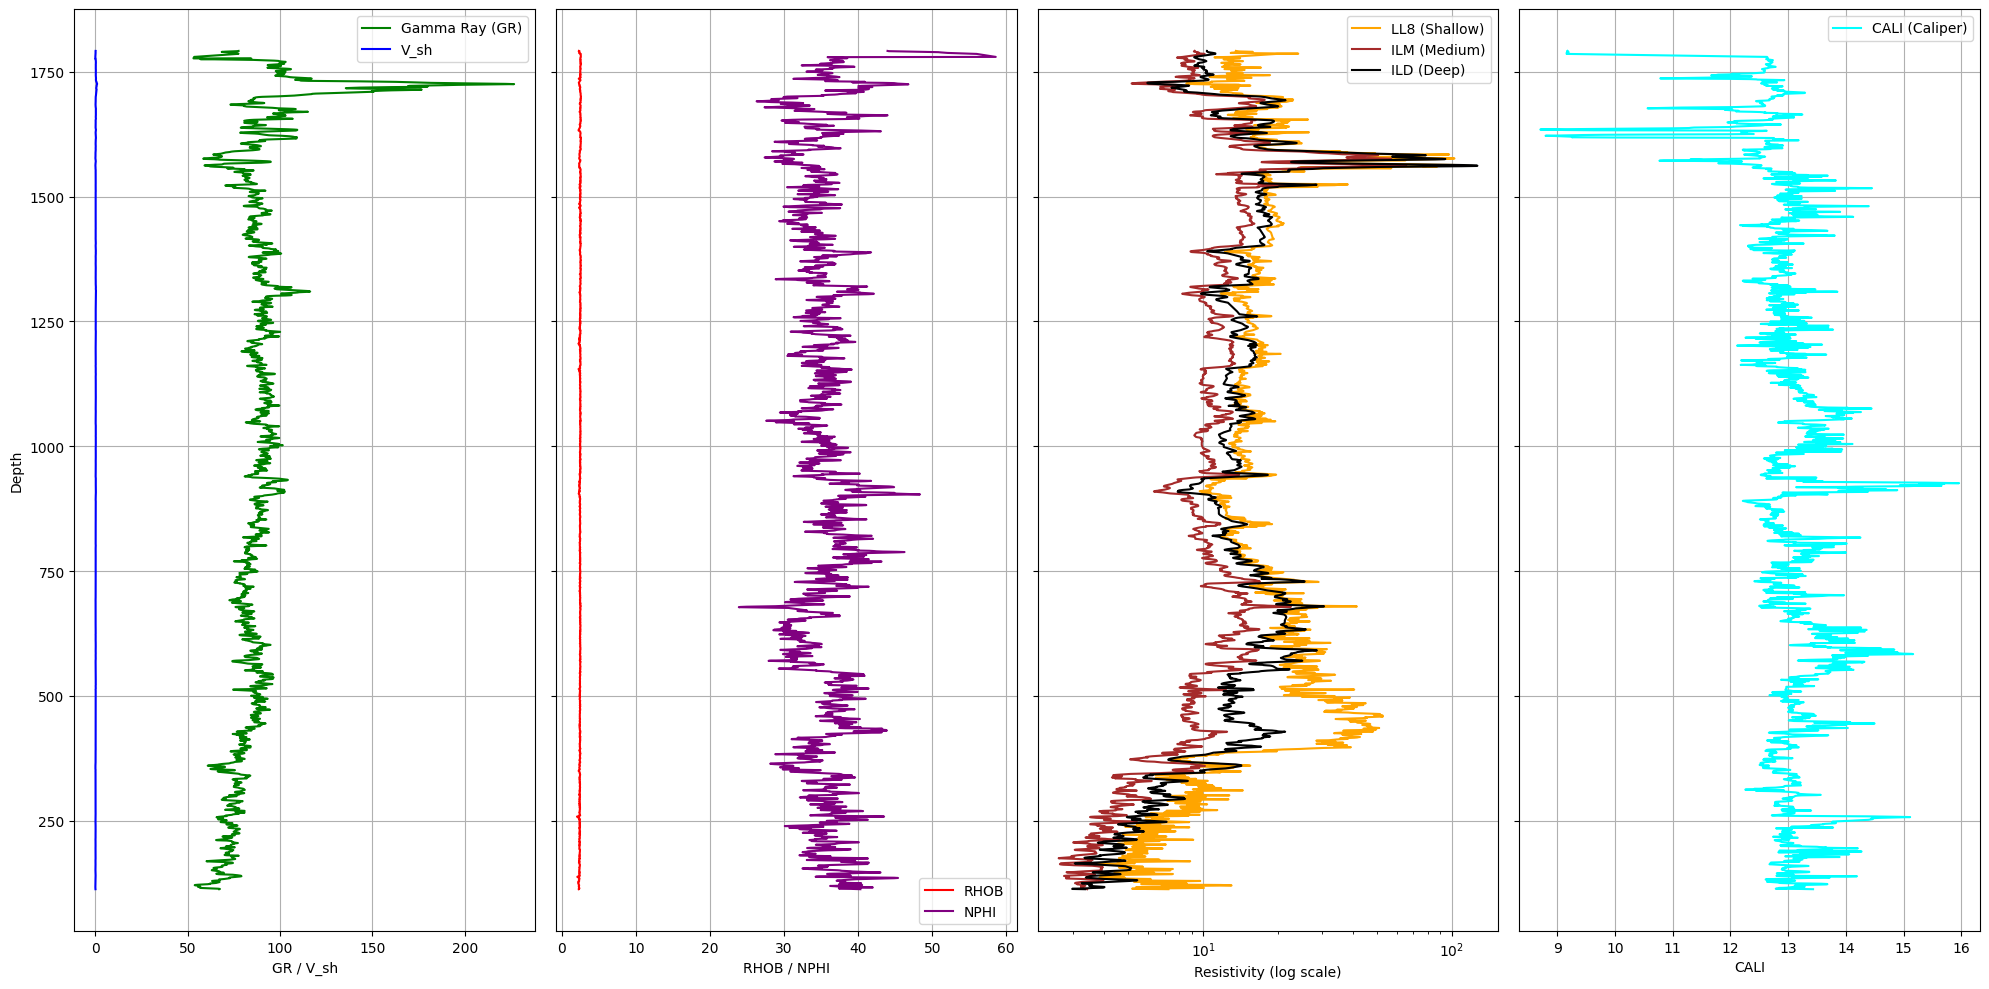

In [ ]:
# Paso  5
# aquí creo los track para ver los datos del pozo
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 10), sharey=True)

# Track 1: Gamma Ray y V_sh
# Visualizo el registro Gamma Ray junto con la concentración volumétrica de lutita.
axes[0].plot(df['GR'], df.index, label='Gamma Ray (GR)', color='green')
axes[0].plot(df['V_sh'], df.index, label='V_sh', color='blue')
axes[0].set_xlabel('GR / V_sh')
axes[0].set_ylabel('Depth')
axes[0].invert_yaxis()
axes[0].legend()
axes[0].grid()

# Track 2: RHOB y NPHI
# Comparo la densidad y la porosidad neutrónica para identificar tendencias.
axes[1].plot(df['RHOB'], df.index, label='RHOB', color='red')
axes[1].plot(df['NPHI'], df.index, label='NPHI', color='purple')
axes[1].set_xlabel('RHOB / NPHI')
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid()

# Track 3: Resistividad (LL8, ILM, ILD)
# Uso una escala logarítmica para visualizar los registros de resistividad.
axes[2].semilogx(df['LL8'], df.index, label='LL8 (Shallow)', color='orange')
axes[2].semilogx(df['ILM'], df.index, label='ILM (Medium)', color='brown')
axes[2].semilogx(df['ILD'], df.index, label='ILD (Deep)', color='black')
axes[2].set_xlabel('Resistivity (log scale)')
axes[2].invert_yaxis()
axes[2].legend()
axes[2].grid()

# Track 4: Otros registros interesantes
# Aquí incluyo un registro adicional para análisis complementario.
axes[3].plot(df['CALI'], df.index, label='CALI (Caliper)', color='cyan')
axes[3].set_xlabel('CALI')
axes[3].invert_yaxis()
axes[3].legend()
axes[3].grid()

# Uso tight_layout para asegurarme de que los gráficos no se solapen.
plt.tight_layout()
plt.show()

In [ ]:
# Paso 6
# Determinar resistividad del agua (R_w) y resistividad de la arena (R_s)
R_w = df['ILD'].min()  # Resistividad en formación de agua pura
R_s = df['ILD'].max()  # Resistividad en formación de arena pura

# Calcular propiedades petrofísicas
df['phi_T'] = (1 - df['V_sh']) * df['phi'] + df['V_sh'] * NPHI_sh
df['S_w'] = (R_w / (R_s * df['phi']**2))**0.5
A, B, C = 1, 2, 2  # Constantes para el cálculo de permeabilidad
df['k'] = (A * df['phi']**B) / (df['S_w']**C)
df['HPV'] = (1 - df['S_w']) * df['phi']

# Mostrar las primeras filas con los nuevos cálculos
df[['phi_T', 'S_w', 'k', 'HPV']].head()

,phi_T,S_w,k,HPV
M__DEPTH,,,,
112.5,29.600991,0.005447,2.662528e+07,27.952125
113.0,28.935012,0.005600,2.382517e+07,27.182118
113.5,28.103739,0.005766,2.119571e+07,26.394517
114.0,27.271554,0.005882,1.957909e+07,25.873155
114.5,27.103539,0.005812,2.054055e+07,26.186948


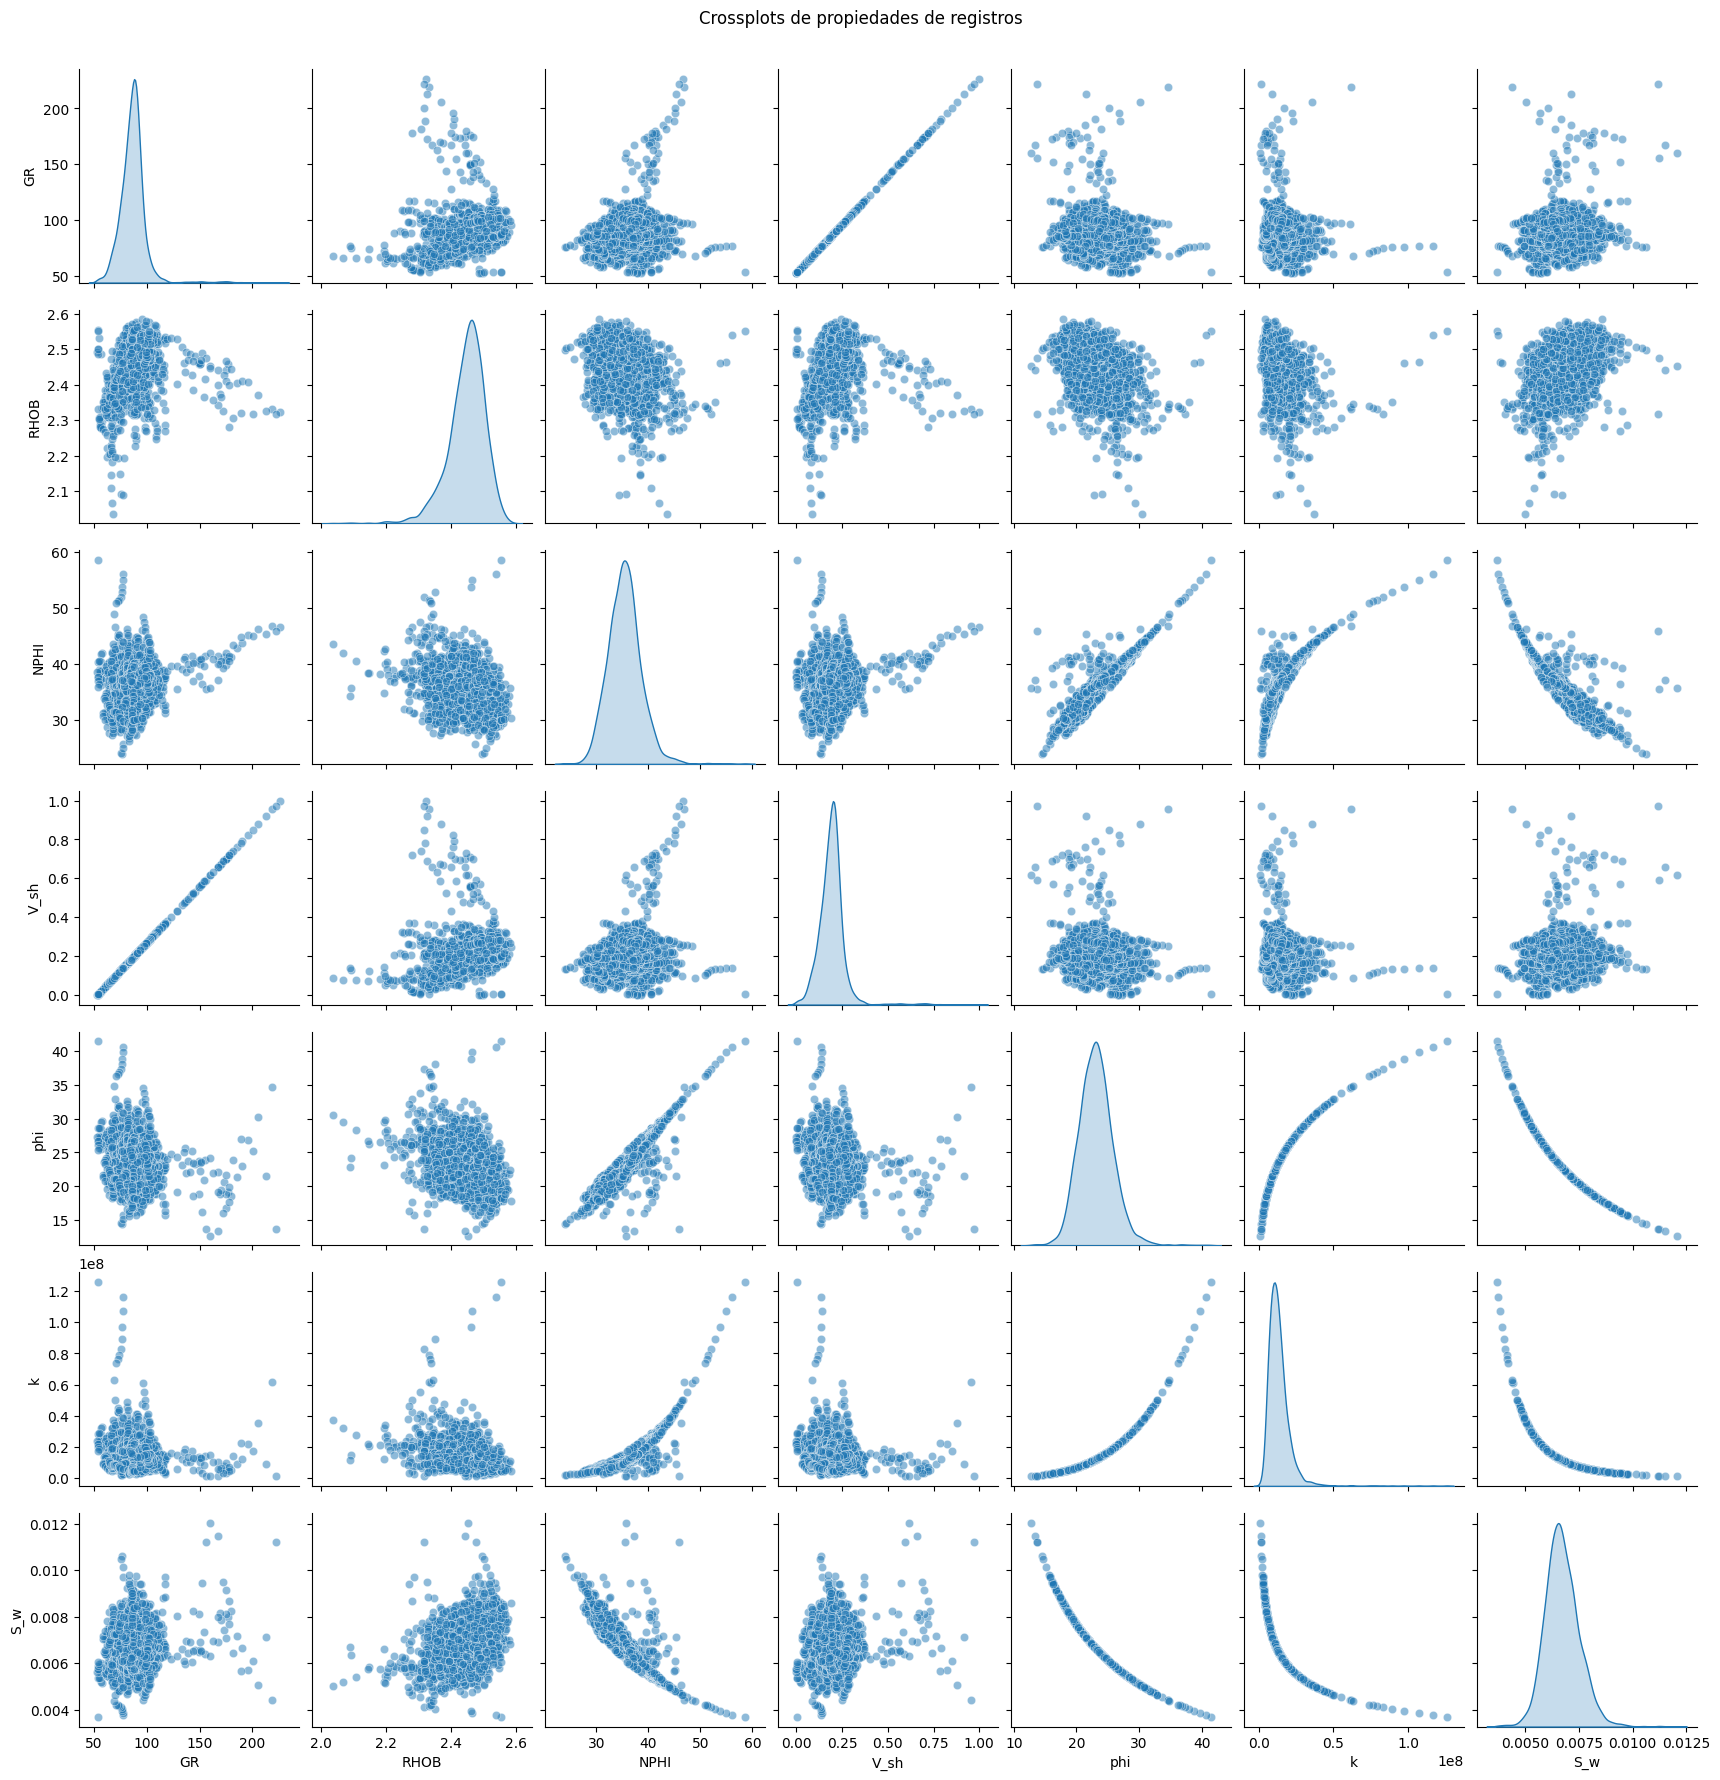

In [ ]:
# Paso 7: Crear crossplots (gráficos de dispersión 3x3)
import seaborn as sns

properties = ['GR', 'RHOB', 'NPHI', 'V_sh', 'phi', 'k', 'S_w']

# Crear una figura para los crossplots
sns.pairplot(df[properties], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Crossplots de propiedades de registros', y=1.02)
plt.show()

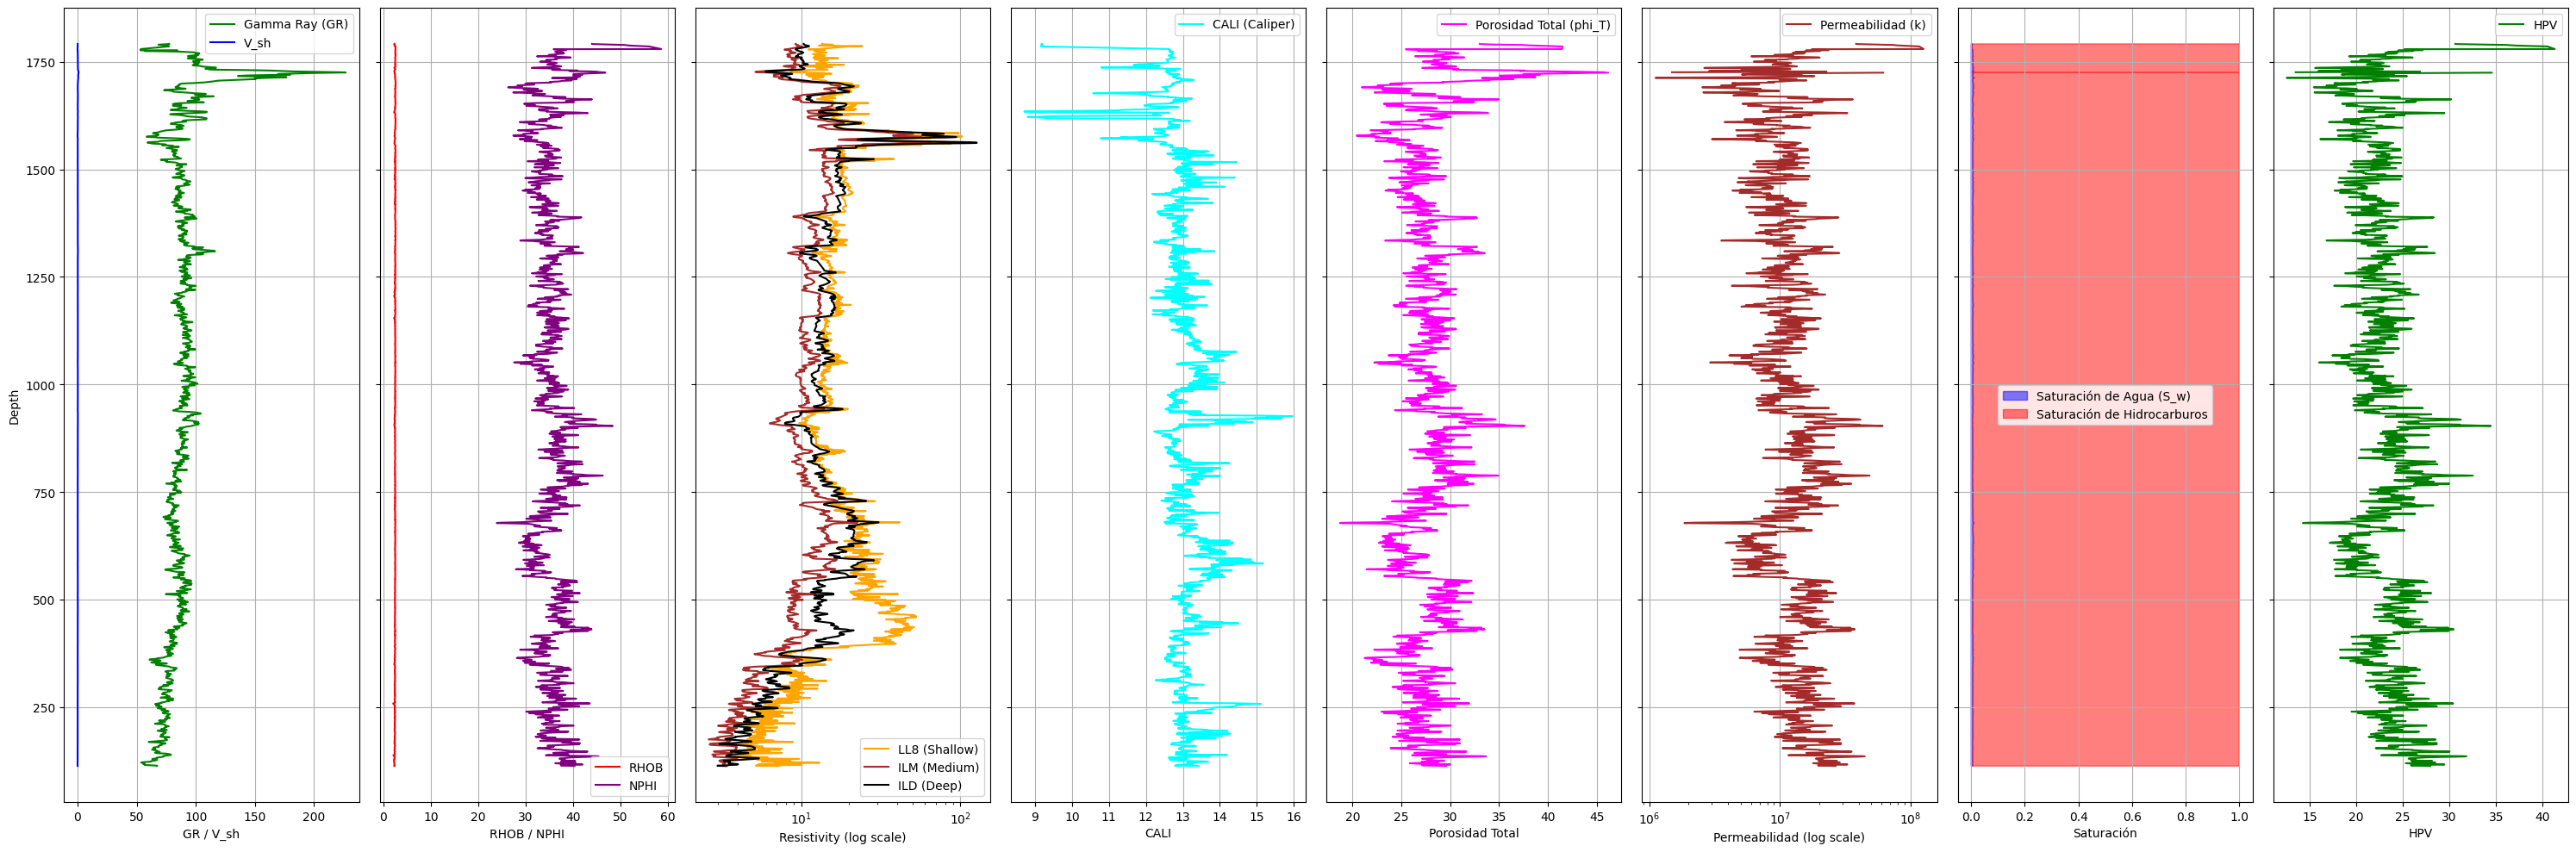

In [ ]:
import matplotlib.pyplot as plt

# Paso 8: Gráfico final del conjunto de registros con verificación de columnas
fig, axes = plt.subplots(nrows=1, ncols=8, figsize=(30, 10), sharey=True)

# Track 1: Gamma Ray y V_sh
if 'GR' in df.columns:
    axes[0].plot(df['GR'], df.index, label='Gamma Ray (GR)', color='green')
if 'V_sh' in df.columns:
    axes[0].plot(df['V_sh'], df.index, label='V_sh', color='blue')
axes[0].set_xlabel('GR / V_sh')
axes[0].set_ylabel('Depth')
axes[0].invert_yaxis()
axes[0].legend()
axes[0].grid()

# Track 2: RHOB y NPHI
if 'RHOB' in df.columns:
    axes[1].plot(df['RHOB'], df.index, label='RHOB', color='red')
if 'NPHI' in df.columns:
    axes[1].plot(df['NPHI'], df.index, label='NPHI', color='purple')
axes[1].set_xlabel('RHOB / NPHI')
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid()

# Track 3: Resistividad (LL8, ILM, ILD)
if 'LL8' in df.columns:
    axes[2].semilogx(df['LL8'], df.index, label='LL8 (Shallow)', color='orange')
if 'ILM' in df.columns:
    axes[2].semilogx(df['ILM'], df.index, label='ILM (Medium)', color='brown')
if 'ILD' in df.columns:
    axes[2].semilogx(df['ILD'], df.index, label='ILD (Deep)', color='black')
axes[2].set_xlabel('Resistivity (log scale)')
axes[2].invert_yaxis()
axes[2].legend()
axes[2].grid()

# Track 4: Otros registros interesantes
if 'CALI' in df.columns:
    axes[3].plot(df['CALI'], df.index, label='CALI (Caliper)', color='cyan')
axes[3].set_xlabel('CALI')
axes[3].invert_yaxis()
axes[3].legend()
axes[3].grid()

# Track 5: Porosidad total
if 'phi_T' in df.columns:
    axes[4].plot(df['phi_T'], df.index, label='Porosidad Total (phi_T)', color='magenta')
axes[4].set_xlabel('Porosidad Total')
axes[4].invert_yaxis()
axes[4].legend()
axes[4].grid()

# Track 6: Permeabilidad
if 'k' in df.columns:
    axes[5].semilogx(df['k'], df.index, label='Permeabilidad (k)', color='brown')
axes[5].set_xlabel('Permeabilidad (log scale)')
axes[5].invert_yaxis()
axes[5].legend()
axes[5].grid()

# Track 7: Saturación
if 'S_w' in df.columns:
    axes[6].fill_betweenx(df.index, 0, df['S_w'], color='blue', alpha=0.5, label='Saturación de Agua (S_w)')
    axes[6].fill_betweenx(df.index, df['S_w'], 1, color='red', alpha=0.5, label='Saturación de Hidrocarburos')
axes[6].set_xlabel('Saturación')
axes[6].invert_yaxis()
axes[6].legend()
axes[6].grid()

# Track 8: Volumen poroso de hidrocarburos
if 'HPV' in df.columns:
    axes[7].plot(df['HPV'], df.index, label='HPV', color='green')
axes[7].set_xlabel('HPV')
axes[7].invert_yaxis()
axes[7].legend()
axes[7].grid()

plt.tight_layout()
plt.show()


In [ ]:
#Actividad 3

In [ ]:
# Importo las librerías necesarias para la manipulación de datos y la visualización.
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
#  ruta del archivo para la realización de permeabilidad 2D y la máscara 
base_dir = r"C:\Users\yoner\OneDrive\Escritorio\AI-CURSO\Intro-AI-NRG-2026\Course Content\Week 1 - Introduction\data\egg_model\2D"
perm_file = os.path.join(base_dir, "PERM29.npy")
mask_file = os.path.join(base_dir, "ACTIVE.npy")

# Cargo la realización de permeabilidad 2D y la máscara de celdas activas.
permeabilidad = np.load(perm_file)
mascara_activa = np.load(mask_file)

# Muestro las formas de los arreglos cargados para verificar que se cargaron 
print("Forma de la realización de permeabilidad:", permeabilidad.shape)
print("Forma de la máscara activa:", mascara_activa.shape)

Forma de la realización de permeabilidad: (60, 60)
Forma de la máscara activa: (60, 60)


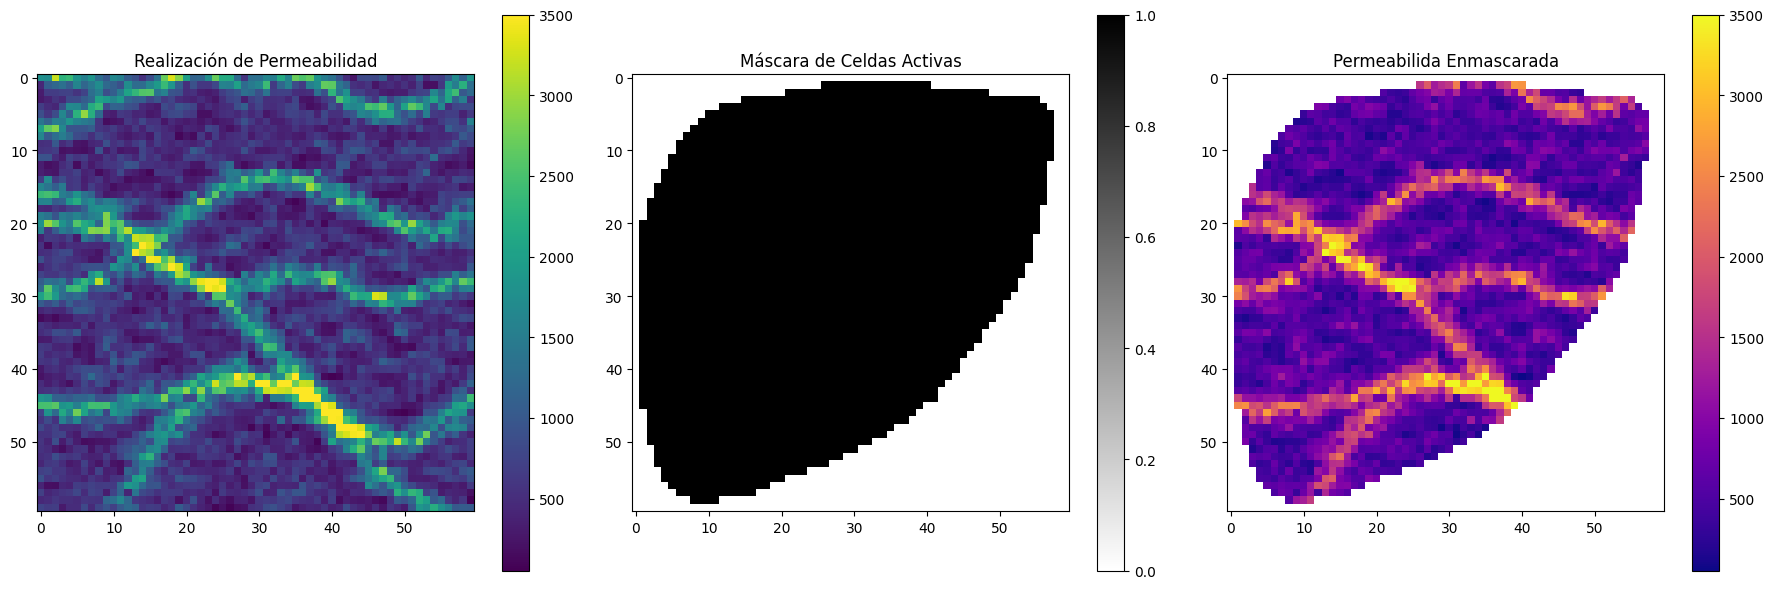

In [ ]:
# Creo un subplot 1x3 para visualizar los datos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Visualizo la realización de permeabilidad.
# Aquí estoy mostrando la realización de permeabilidad utilizando un mapa de colores 'viridis'.
im1 = axes[0].imshow(permeabilidad, cmap='viridis')
axes[0].set_title("Realización de Permeabilidad")
fig.colorbar(im1, ax=axes[0])

# Visualizo la máscara de celdas activas.
# Estoy utilizando un mapa de colores binario para mostrar las celdas activas e inactivas.
im2 = axes[1].imshow(mascara_activa, cmap='binary')
axes[1].set_title("Máscara de Celdas Activas")
fig.colorbar(im2, ax=axes[1])

# Visualizo la permeabilidad enmascarada.
# Estoy enmascarando las celdas inactivas (valor 0 en la máscara) y visualizándolas con un mapa de colores 'plasma'.
permeabilidad_enmascarada = np.ma.masked_where(mascara_activa == 0, permeabilidad)
im3 = axes[2].imshow(permeabilidad_enmascarada, cmap='plasma')
axes[2].set_title("Permeabilida Enmascarada")
fig.colorbar(im3, ax=axes[2])

# Ajusto el diseño para evitar solapamientos y muestro el gráfico final.
plt.tight_layout()
plt.show()